In [5]:
import numpy as np
import dpluspy
import pickle
import matplotlib.pyplot as plt

In [6]:
rmaps = [
    "Bherer",
    "ZhouJHS",
    "ZhouFHS",
    "hapmap",
    "Hinch",
    "omniFIN",
    "omniLWK",
    "omniYRI",
    "pyrhoFIN",
    "pyrhoLWK",
    "pyrhoYRI"
]

In [7]:
def run_bootstrap(in_fnames, out_fname):
    sums = {}
    for fname in in_fnames:
        try:
            with open(fname, "rb") as fin:
                chrom_sums = pickle.load(fin)
            sums.update(chrom_sums)
        except:
            print(f"lacking file {fname}")
    bins = sums[next(iter(sums))]["bins"]
    pop_ids = sums[next(iter(sums))]["pop_ids"]
    means, varcovs = dpluspy.bootstrapping.bootstrap_stats(sums, num_reps=500)
    data = {
        "means": means, "varcovs": varcovs, "bins": bins, "pop_ids": pop_ids}
    data = dpluspy.bootstrapping.subset_stats(
        data, min_r=1e-6, max_r=1e-2, return_dict=True)
    with open(out_fname, "wb") as fout:
        pickle.dump(data, fout)
    return


for rmap in rmaps:
    fnames = [f"results/sums/sums_{rmap}_chr{j}.pkl" for j in range(1, 23)]
    out_fname = f"results/stats/stats_{rmap}.pkl"
    run_bootstrap(fnames, out_fname)

lacking file results/sums/sums_hapmap_chr6.pkl
lacking file results/sums/sums_hapmap_chr7.pkl


In [8]:
# Load statistics
pops_to_plot = ["Vindija", "Denisova", "UstIshim", "Yoruba1", "Yoruba3"]
means = []
varcovs = []

for rmap in rmaps:
    fname = f"results/stats/stats_{rmap}.pkl"
    pop_ids, bins, _means, _varcovs = dpluspy.inference.load_stats(
        fname, to_pops=pops_to_plot)
    means.append(_means)
    varcovs.append(_varcovs)

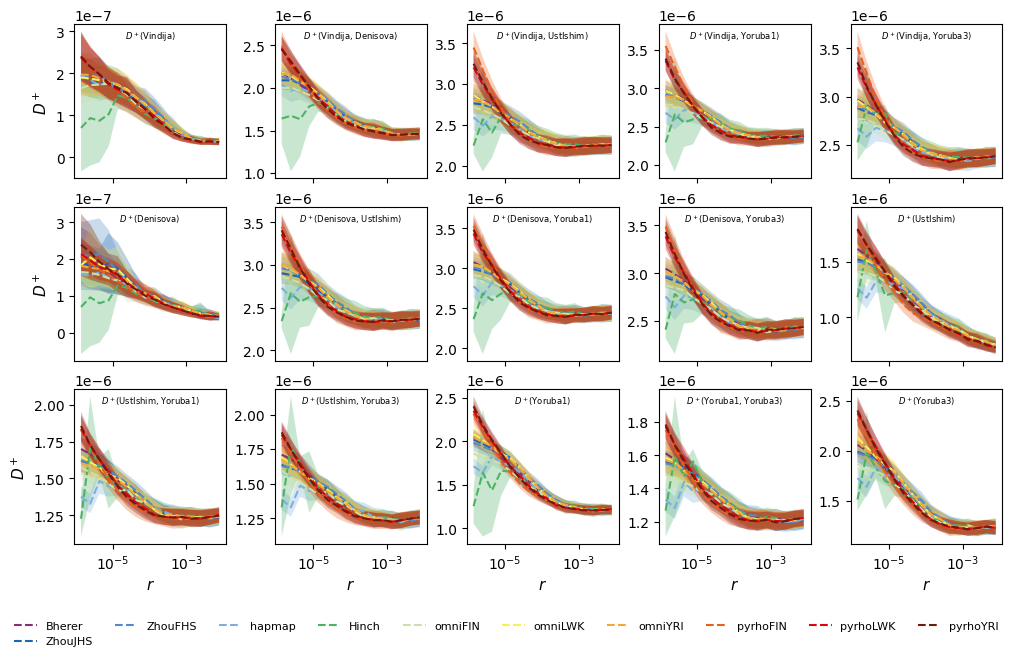

In [9]:
# Plot a summary for five samples
dpluspy.plotting.plot_D_plus_curves(means=means, varcovs=varcovs, bins=bins,
    pop_ids=pop_ids, labels=rmaps)